In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import joblib


In [2]:
df = pd.read_csv('../data/fraudTrain.csv')
df.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

---

Handling missing values

In [4]:
na_count = df.isnull().sum()
na_count[na_count > 0]

Series([], dtype: int64)

---

Handling duplicates

In [5]:
df.duplicated().sum()

0

---

Target distribution

is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64
Countplot distribution of 'is_fraud' column:


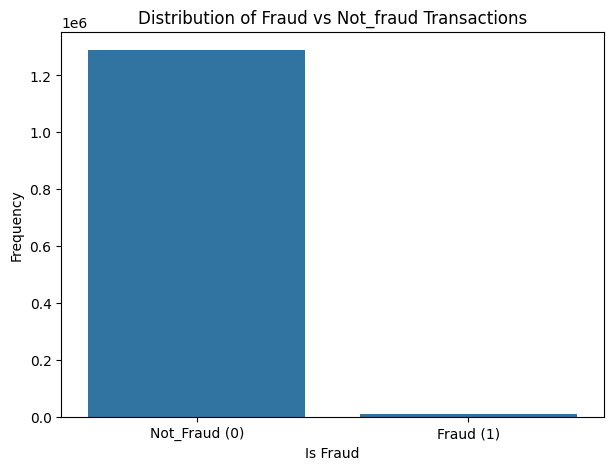

In [6]:
# "is_fraud"column i.e. target variable distribution
print(df["is_fraud"].value_counts(normalize=True))

# Countplot of target variable
print("Countplot distribution of 'is_fraud' column:")
plt.figure(figsize= (7,5))
sns.countplot(x='is_fraud', data=df)
plt.title('Distribution of Fraud vs Not_fraud Transactions')
plt.xlabel("Is Fraud")
plt.ylabel("Frequency")
plt.xticks([0, 1], ['Not_Fraud (0)', 'Fraud (1)'])
plt.show()


Shows significant imbalance in target variables.<br>
Later, May use undersampling or oversampling or hybrid of both

---

Calculate and display descriptive statistics for all numerical columns. Visualize their distributions using histograms and box plots to understand their spread, central tendency, and identify outliers. Provide appropriate legends for all plots.


Descriptive Statistics for Numerical Features (excluding id and target columns):
                amt           zip           lat          long      city_pop  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean   7.035104e+01  4.880067e+04  3.853762e+01 -9.022634e+01  8.882444e+04   
std    1.603160e+02  2.689322e+04  5.075808e+00  1.375908e+01  3.019564e+05   
min    1.000000e+00  1.257000e+03  2.002710e+01 -1.656723e+02  2.300000e+01   
25%    9.650000e+00  2.623700e+04  3.462050e+01 -9.679800e+01  7.430000e+02   
50%    4.752000e+01  4.817400e+04  3.935430e+01 -8.747690e+01  2.456000e+03   
75%    8.314000e+01  7.204200e+04  4.194040e+01 -8.015800e+01  2.032800e+04   
max    2.894890e+04  9.978300e+04  6.669330e+01 -6.795030e+01  2.906700e+06   

          unix_time     merch_lat    merch_long  
count  1.296675e+06  1.296675e+06  1.296675e+06  
mean   1.349244e+09  3.853734e+01 -9.022646e+01  
std    1.284128e+07  5.109788e+00  1.377109e+01  
min   

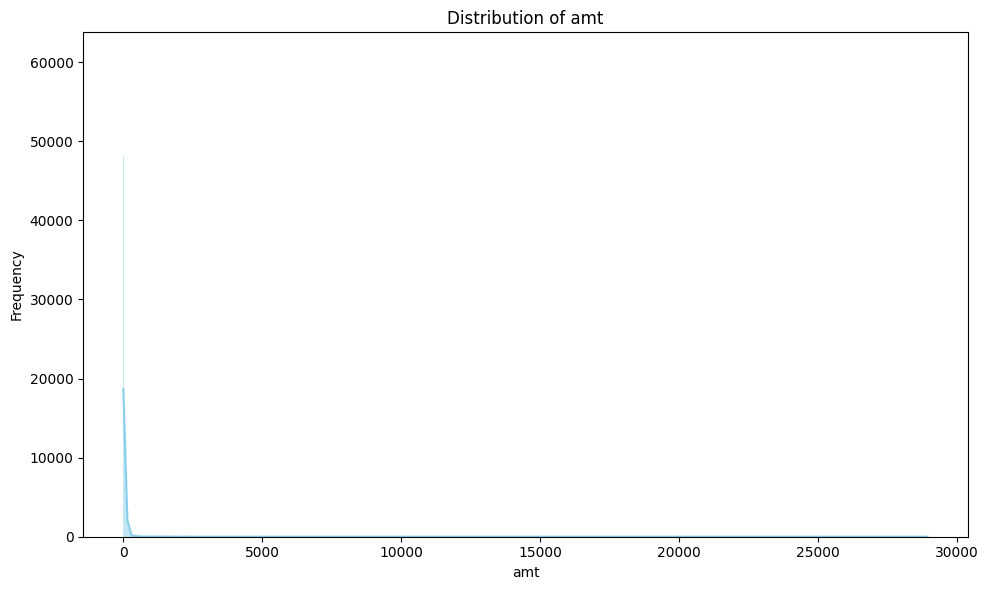

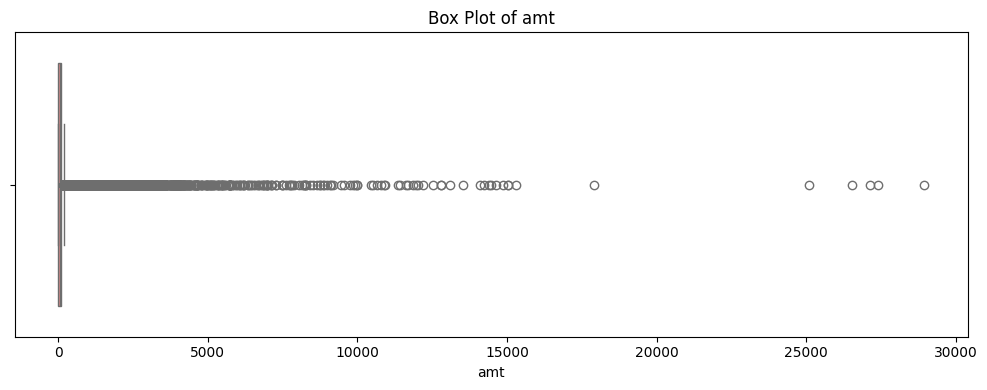

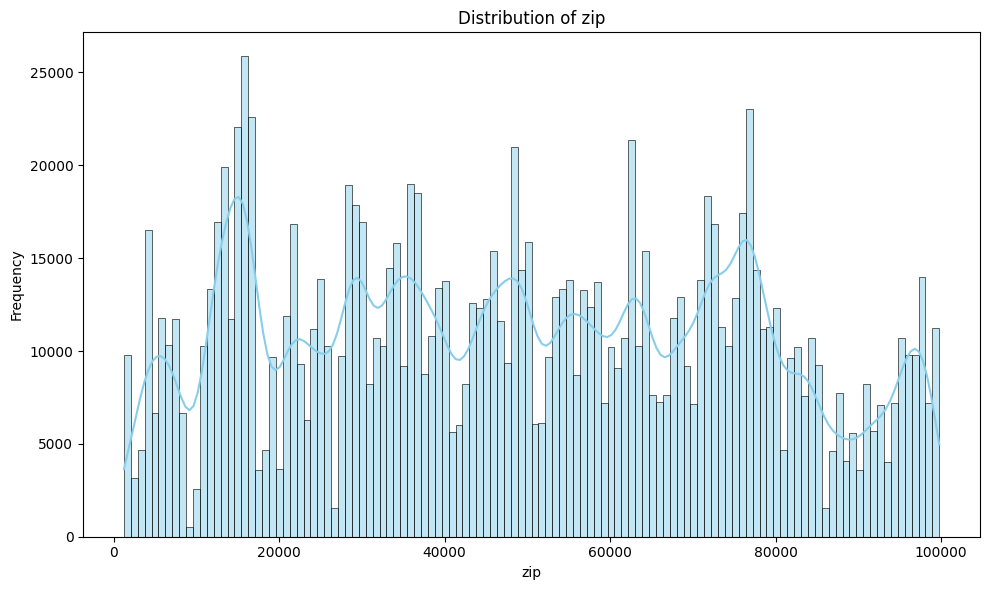

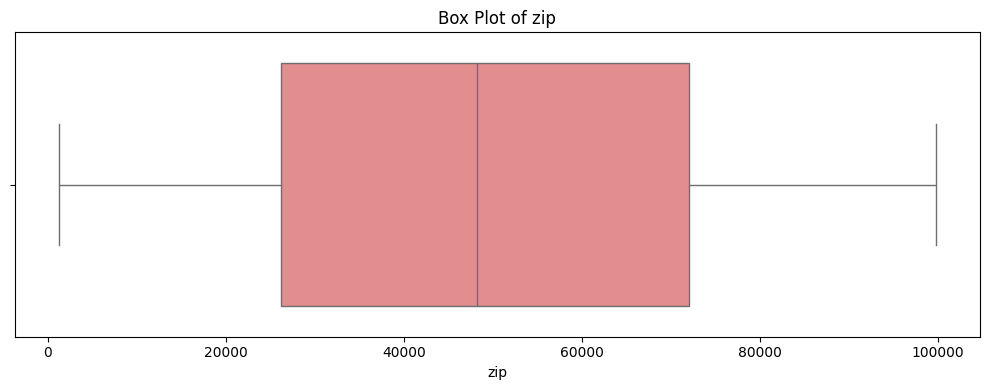

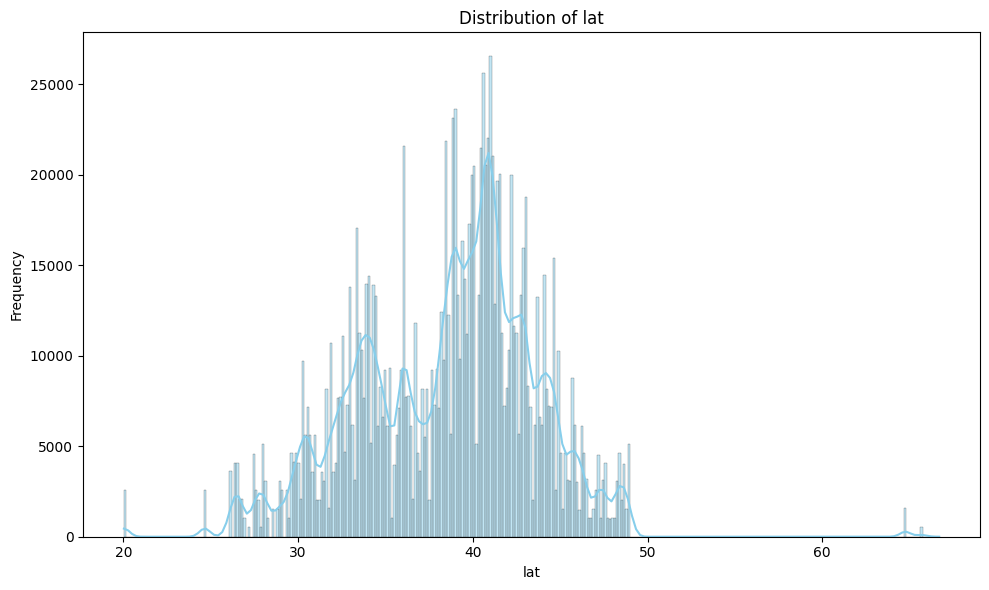

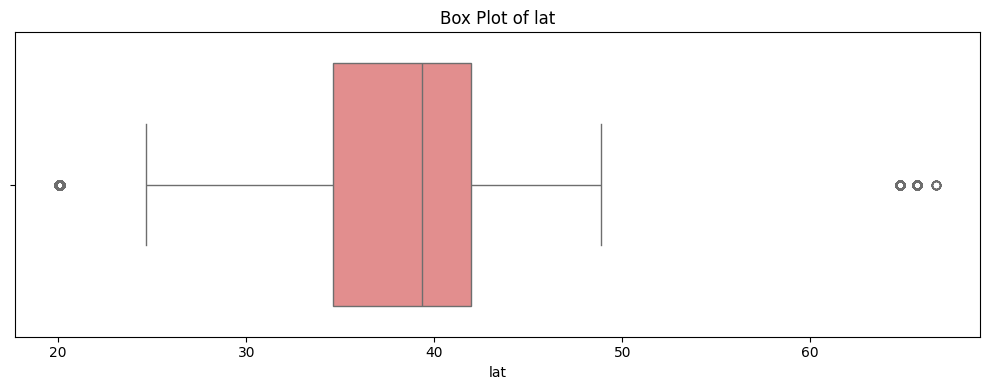

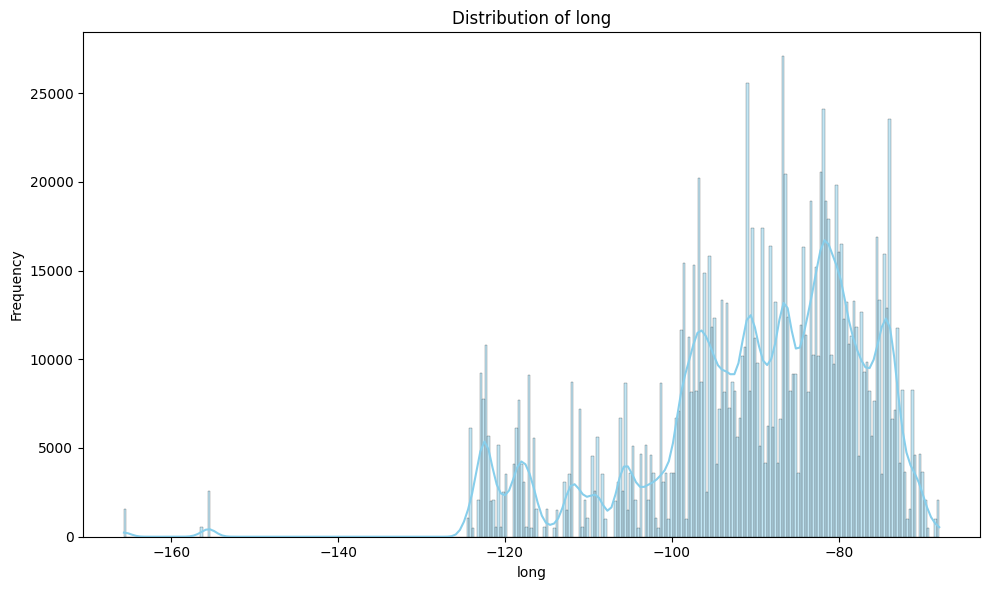

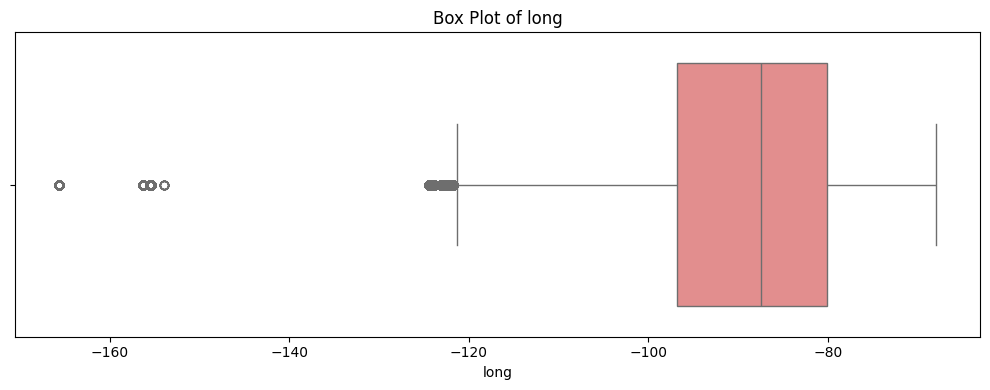

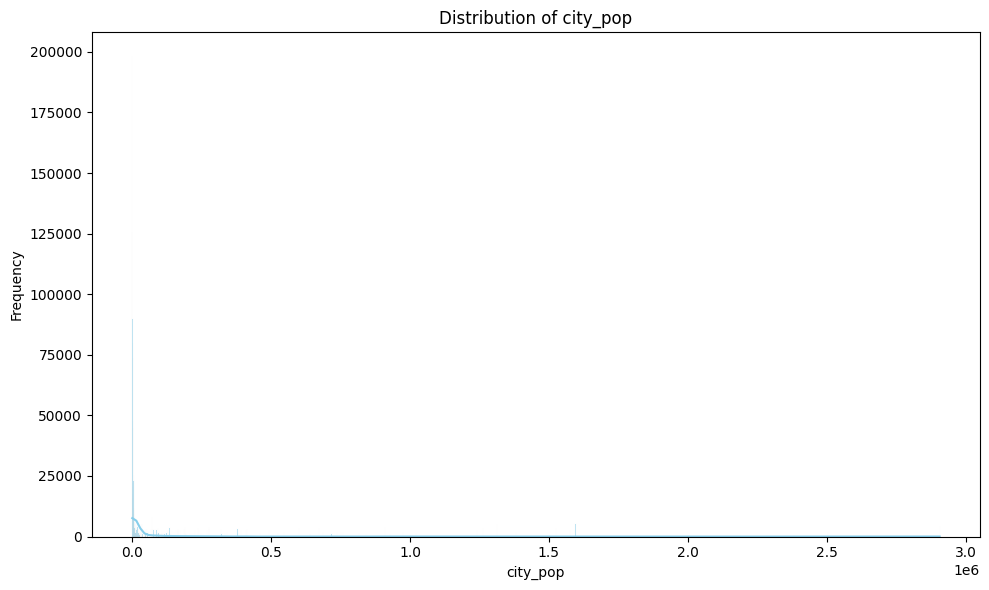

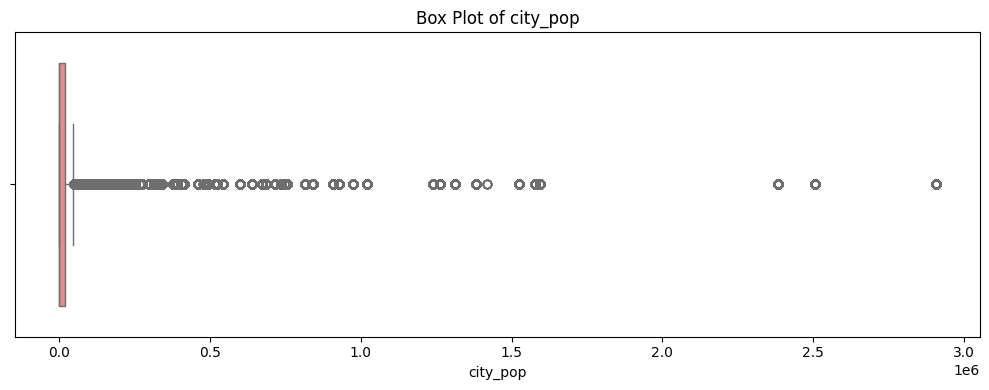

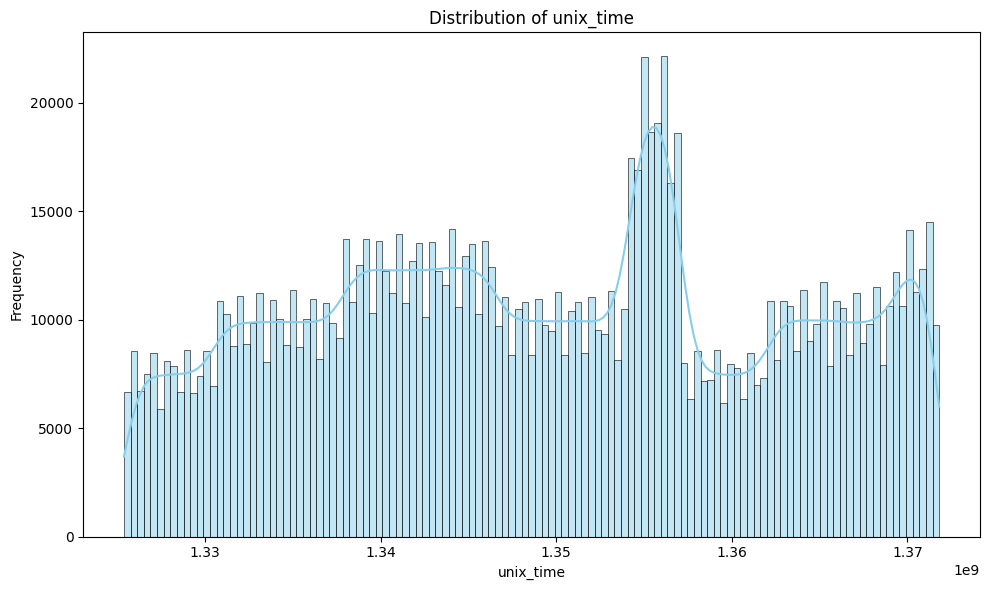

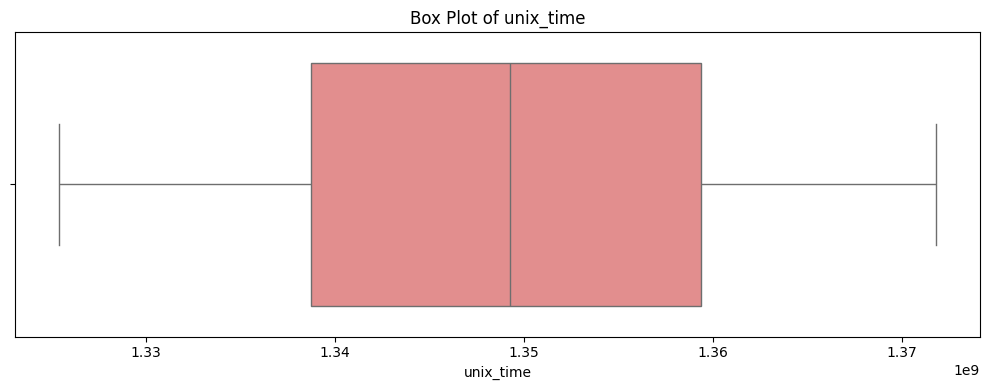

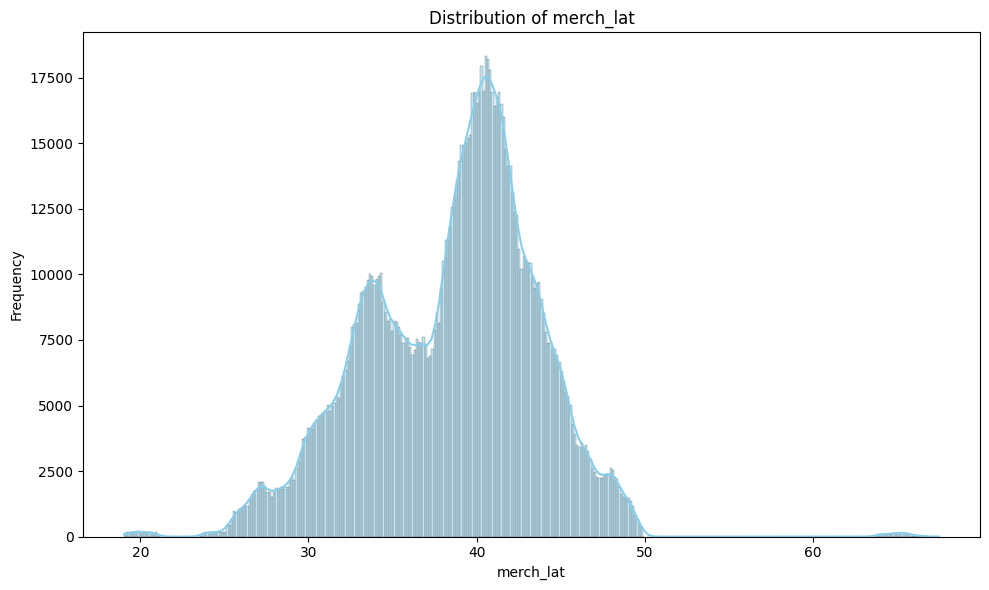

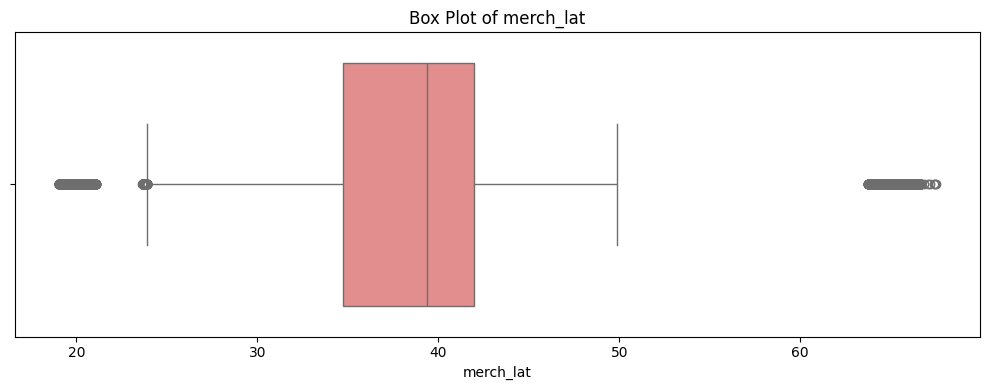

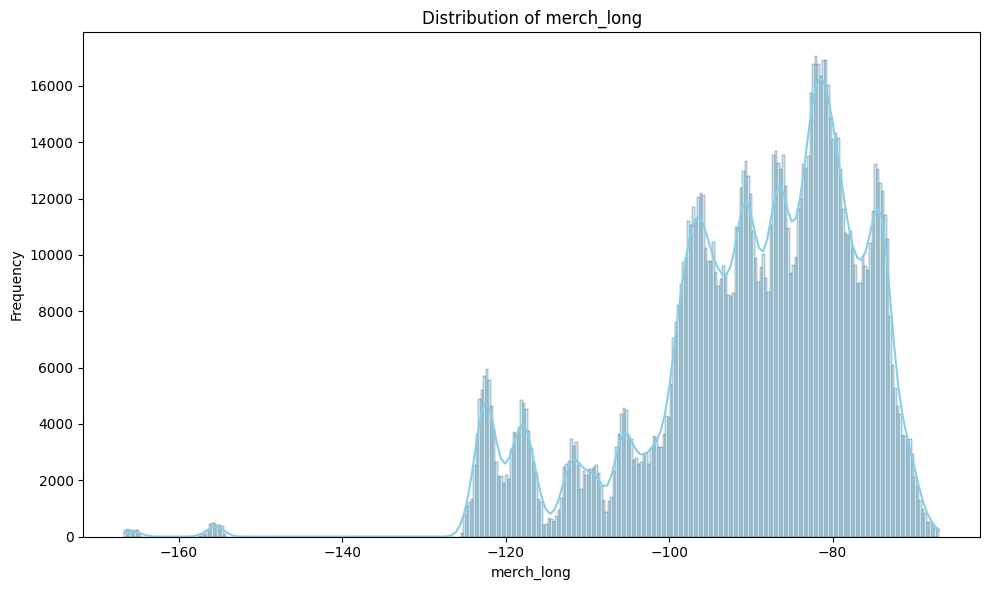

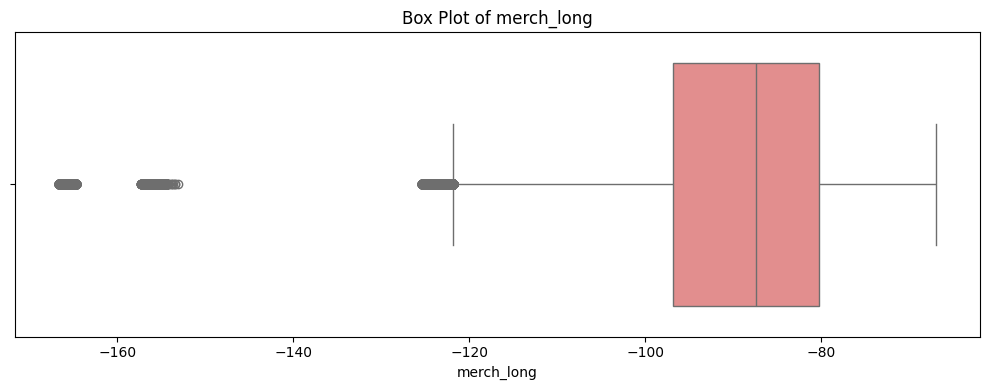

In [7]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude 'Unnamed: 0', 'cc_num', and 'is_fraud' as specified
exclude_cols = ['Unnamed: 0', 'cc_num', 'is_fraud']
eda_numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

print("\nDescriptive Statistics for Numerical Features (excluding id and target columns):")
print(df[eda_numerical_cols].describe())

for col in eda_numerical_cols:
    # Histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    # Box plot
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

---

Distributions of categorical features, specifically 'category' and 'gender', using count plots to understand their frequency and patterns

Distribution of 'category' column:


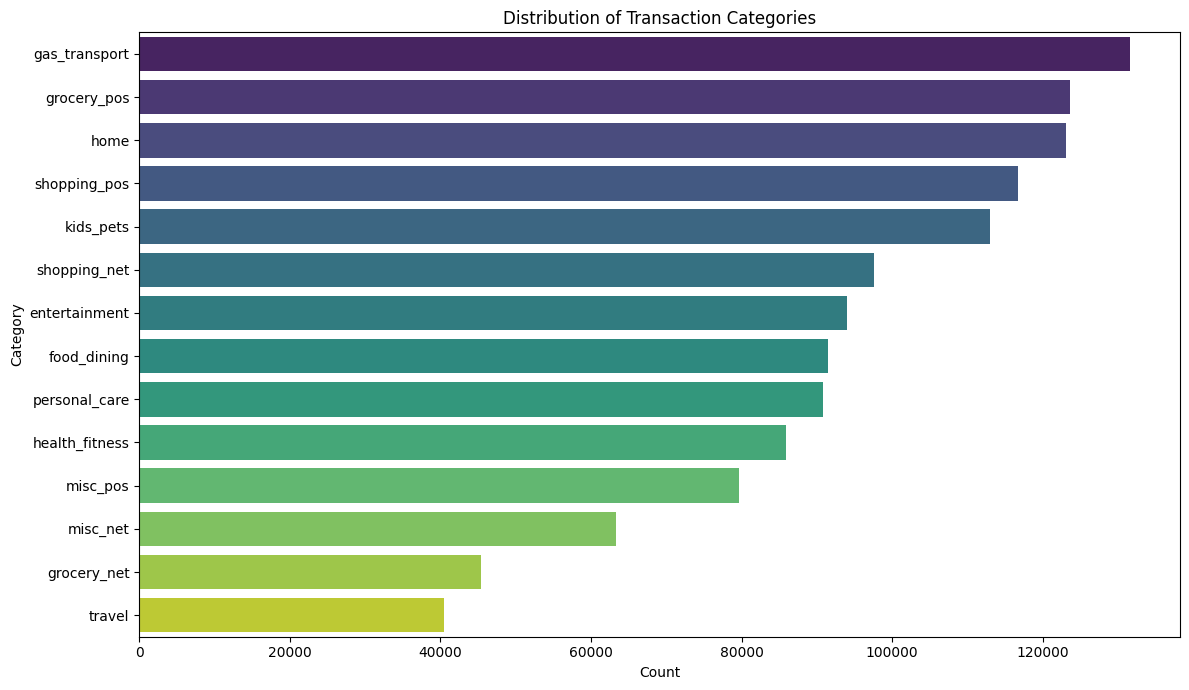


Distribution of 'gender' column:


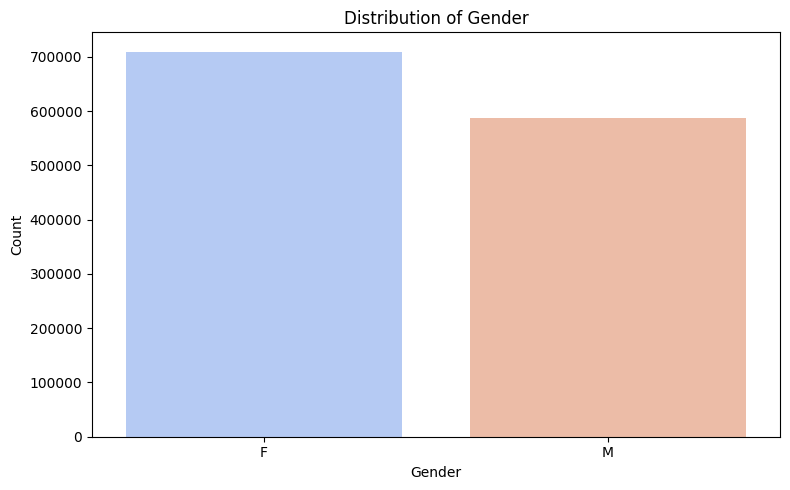

In [8]:
print("Distribution of 'category' column:")
plt.figure(figsize=(12, 7))
sns.countplot(y='category', data=df, palette='viridis', order=df['category'].value_counts().index)
plt.title('Distribution of Transaction Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

print("\nDistribution of 'gender' column:")
plt.figure(figsize=(8, 5))
sns.countplot(x='gender', data=df, palette='coolwarm')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

convert the 'trans_date_trans_time' column to datetime objects to enable time-based analysis<br>
To analyze transaction patterns over time, I will extract 'hour of day', 'day of week', and 'month' from the trans_date_trans_time column and add them as new features to the DataFrame.<br>

In [9]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour_of_day'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
df['month'] = df['trans_date_trans_time'].dt.month

print("DataFrame with new time features:")
df[["trans_date_trans_time","hour_of_day", "day_of_week", "month"]].head()

DataFrame with new time features:


,trans_date_trans_time,hour_of_day,day_of_week,month
0,2019-01-01 00:00:18,0,1,1
1,2019-01-01 00:00:44,0,1,1
2,2019-01-01 00:00:51,0,1,1
3,2019-01-01 00:01:16,0,1,1
4,2019-01-01 00:03:06,0,1,1


Visualize the distribution of total transactions and fraudulent transactions across these time periods to identify any patterns or trends

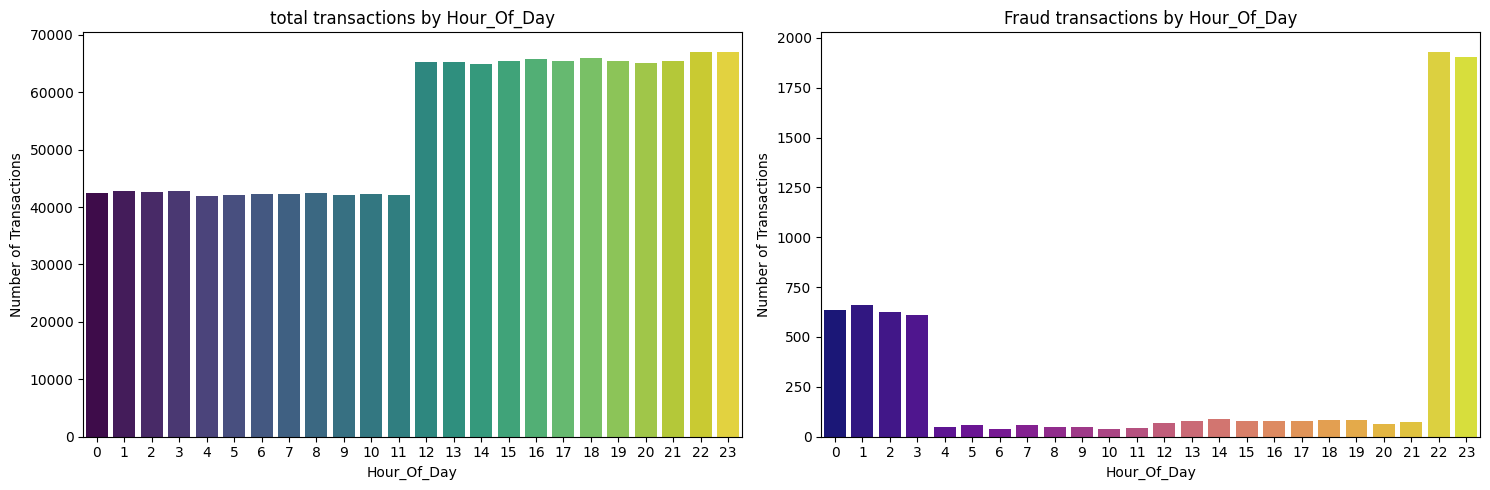

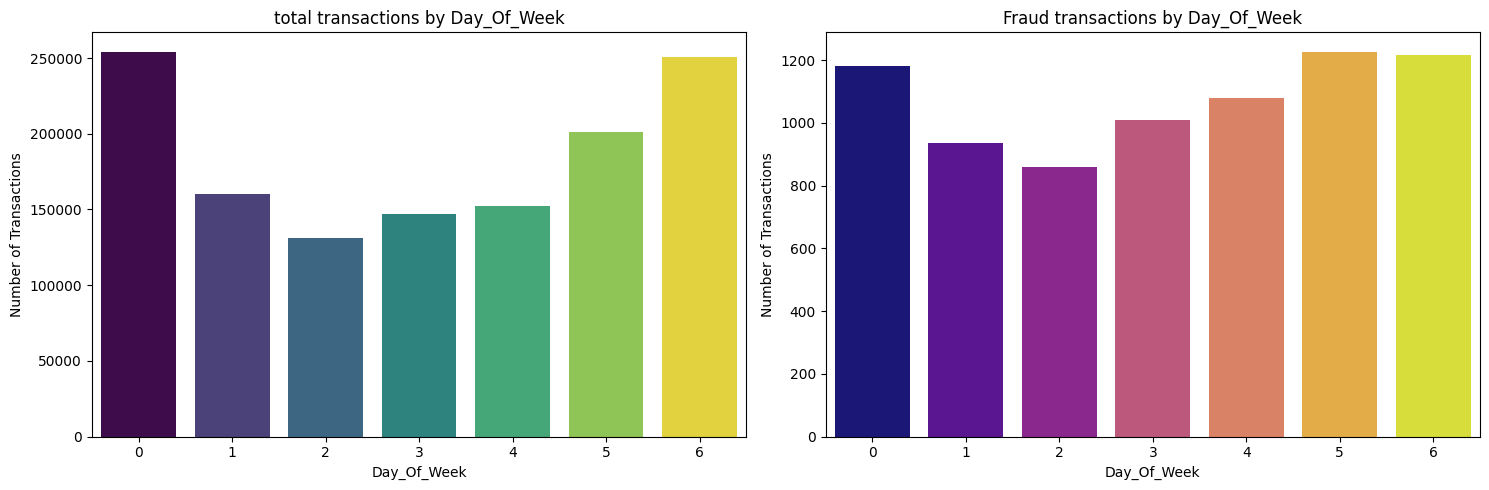

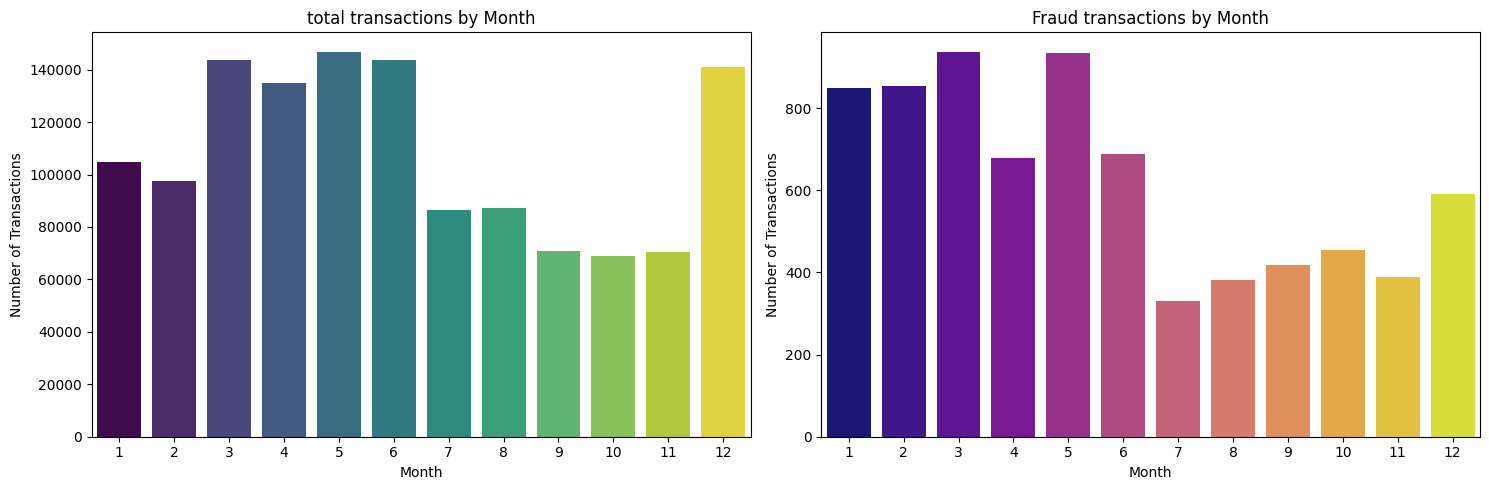

In [10]:
time_features = ['hour_of_day', "day_of_week", "month"]

for feature in time_features:
    #Total transactions distribution
    
    fig, ax = plt.subplots(1,2, figsize=(15,5))
    sns.countplot(x=feature, data=df, palette = "viridis", hue=feature, legend=False, ax=ax[0])
    ax[0].set_title(f"total transactions by {feature.title()}")
    ax[0].set_xlabel(feature.title())
    ax[0].set_ylabel("Number of Transactions")
   
    #Fraud Transactions distribution
    sns.countplot(x=feature, data=df[df['is_fraud'] == 1], palette = "plasma", hue=feature, legend=False, ax=ax[1])
    ax[1].set_title(f"Fraud transactions by {feature.title()}")
    ax[1].set_xlabel(feature.title())
    ax[1].set_ylabel("Number of Transactions")
    
    plt.tight_layout()
    plt.show()

Correlation Matrix Heatmap

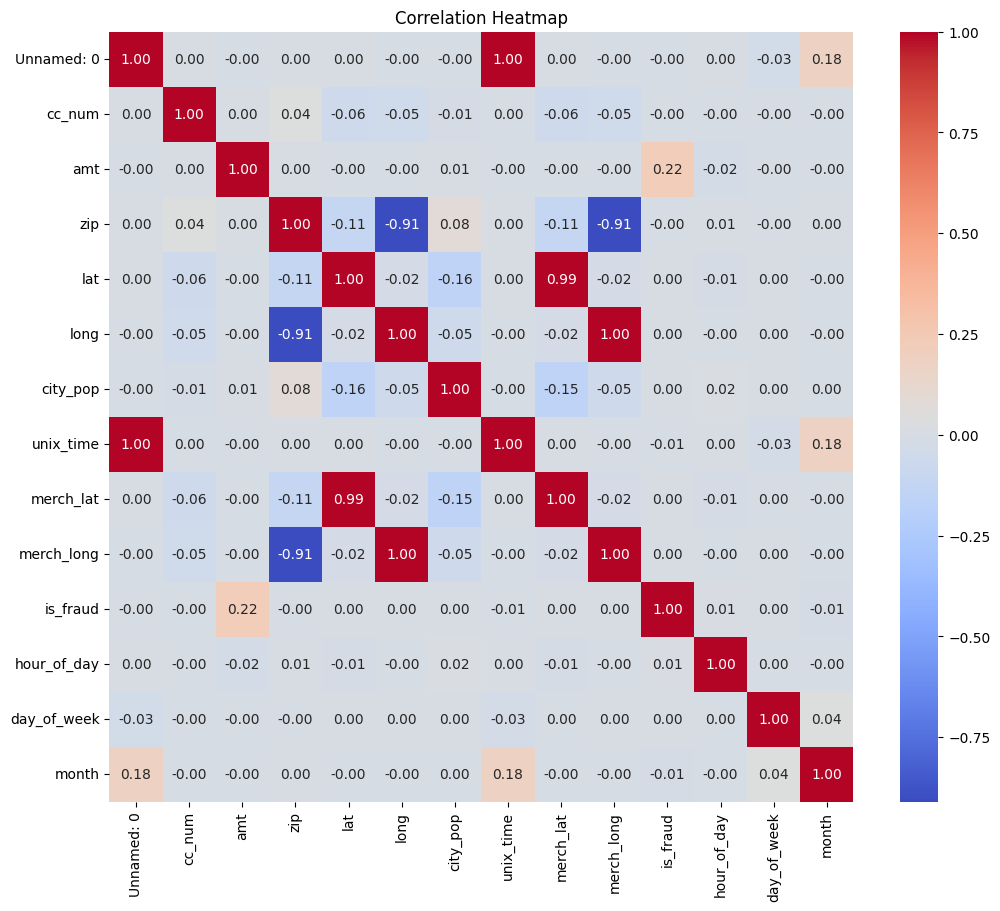

In [11]:
cor_matrix = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12,10))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Missing Values**: A single row containing missing values was dropped, resulting in a clean dataset of  1296675 entries. No duplicate rows were found.
*   **Numerical Feature Distributions**:
    *   Transaction `amt` (amount) and `city_pop` (city population) are heavily right-skewed, indicating a high frequency of smaller values and a few significantly larger outliers.
    *   Geographical coordinates (`zip`, `lat`, `long`, `merch_lat`, `merch_long`) and `city_pop` show diverse distributions.
    *   `unix_time` is uniformly distributed, suggesting transactions are spread consistently over the observed period.
*   **Categorical Feature Distributions**:
    *   'gas\_transport' and 'grocery\_pos' are the most frequent transaction categories.
    *   The `gender` distribution is nearly balanced between 'M' and 'F'.
*   **Fraud Distribution**: The `is_fraud` column is highly imbalanced, with only approximately 0.58% of transactions identified as fraudulent.
*   **Time-based Transaction Patterns**: Transactions vary across `hour_of_day` and `day_of_week`. `month` data indicated transactions occurred in June; however, monthly trends are not fully observable due to the limited time frame. Fraudulent transactions also exhibit specific patterns across these time periods.
*   **Correlation Matrix**: Strong positive correlations exist between `lat` and `merch_lat`, and `long` and `merch_long`, as expected. The `is_fraud` variable shows very weak correlations with most numerical features.

### Insights or Next Steps

*   Address the severe class imbalance in the `is_fraud` column using sampling techniques (e.g., SMOTE, undersampling) or specialized algorithms during model training.
*   Further investigate outliers in `amt` and geographical features, as they could be indicative of fraudulent activities or dataset noise.
*   Utilize time-based patterns of fraudulent transactions (e.g., specific hours or days) as crucial features for developing robust fraud detection models.
*   Engineer new features from existing ones, such as calculating the distance between user and merchant coordinates, which could provide additional predictive power for fraud detection.
